In [ ]:
!pip install -q segment-anything
!pip install -q segmentation-models-pytorch
!pip install -q pycocotools
!pip install -q albumentations
!pip install -q supervision
!pip install -q roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 109.2 MB/s eta 0:00:00


In [ ]:
!pip install -q segment-anything
!pip install -q segmentation-models-pytorch
!pip install -q pycocotools
!pip install -q roboflow
# !pip install -q git+https://github.com/facebookresearch/sam2.git

In [ ]:
import os, cv2, random, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              confusion_matrix, roc_auc_score)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import segmentation_models_pytorch as smp
from segment_anything import sam_model_registry, SamPredictor
from segment_anything.utils.transforms import ResizeLongestSide
from pycocotools.coco import COCO

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [ ]:
os.environ['KAGGLE_CONFIG_DIR'] = "/content"

# PlantVillage
!kaggle datasets download -d emmarex/plantdisease
!unzip -q plantdisease.zip -d plantvillage

# Lesion segmentation dataset
!kaggle datasets download -d fakhrealam9537/leaf-disease-segmentation-dataset
!unzip -q leaf-disease-segmentation-dataset.zip -d lesion_data

# SAM 1 ViT-B checkpoint
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

# SAM 2 checkpoint (small variant — fastest, fits Colab)
!wget -q https://dl.fbaipublicfiles.com/segment_anything_2/sam2.1_hiera_small.pt

# Roboflow leaf segmentation dataset
from roboflow import Roboflow
rf = Roboflow(api_key="yr7HoChnbZ6AlDkphxmj")
project = rf.workspace("leaf-disease-gzllx").project("leaf-60rmy")
dataset = project.version(1).download("coco-segmentation", location="/content/leaf_seg_roboflow")

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:03<00:00, 186MB/s]

Dataset URL: https://www.kaggle.com/datasets/fakhrealam9537/leaf-disease-segmentation-dataset
License(s): CC0-1.0
100% 503M/503M [00:05<00:00, 97.1MB/s]

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/leaf_seg_roboflow in coco-segmentation:: 100%|██████████| 2398/2398 [00:00<00:00, 2786.22it/s]


In [ ]:
# SAM 1
SAM1_CHECKPOINT  = "sam_vit_b_01ec64.pth"
SAM1_MODEL_TYPE  = "vit_b"
SAM1_FINETUNED   = "sam1_leaf_finetuned.pth"

IMAGE_ROOT = "/content/plantvillage/plantvillage/PlantVillage"

LESION_DIRS = [
    ("/content/lesion_data/data/data/images",         "/content/lesion_data/data/data/masks"),
    ("/content/lesion_data/aug_data/aug_data/images", "/content/lesion_data/aug_data/aug_data/masks"),
]

RF_TRAIN_JSON = "/content/leaf_seg_roboflow/train/_annotations.coco.json"
RF_TRAIN_IMGS = "/content/leaf_seg_roboflow/train"
RF_VALID_JSON = "/content/leaf_seg_roboflow/valid/_annotations.coco.json"
RF_VALID_IMGS = "/content/leaf_seg_roboflow/valid"

SAM_FINETUNE_EPOCHS = 10
SAM_FINETUNE_LR     = 1e-4
SAM_FINETUNE_BS     = 4

UNET_EPOCHS      = 50
SEGFORMER_EPOCHS = 50
LESION_LR        = 1e-4
LESION_BS        = 8
IMG_SIZE         = 256

In [ ]:
def compute_iou(pred: np.ndarray, gt: np.ndarray) -> float:
    pred = pred.astype(bool); gt = gt.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return float(inter) / (float(union) + 1e-6)

def compute_dice(pred: np.ndarray, gt: np.ndarray) -> float:
    pred = pred.astype(bool); gt = gt.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    return (2.0 * inter) / (pred.sum() + gt.sum() + 1e-6)

def compute_pixel_accuracy(pred: np.ndarray, gt: np.ndarray) -> float:
    return float((pred == gt).sum()) / float(gt.size)

def compute_precision(pred: np.ndarray, gt: np.ndarray) -> float:
    pred_f = pred.flatten().astype(int)
    gt_f   = gt.flatten().astype(int)
    if pred_f.sum() == 0: return 0.0
    return float(precision_score(gt_f, pred_f, zero_division=0))

def compute_recall(pred: np.ndarray, gt: np.ndarray) -> float:
    return float(recall_score(gt.flatten().astype(int),
                              pred.flatten().astype(int), zero_division=0))

def compute_f1(pred: np.ndarray, gt: np.ndarray) -> float:
    return float(f1_score(gt.flatten().astype(int),
                          pred.flatten().astype(int), zero_division=0))

def compute_specificity(pred: np.ndarray, gt: np.ndarray) -> float:
    tn = np.logical_and(~pred.astype(bool), ~gt.astype(bool)).sum()
    fp = np.logical_and(pred.astype(bool),  ~gt.astype(bool)).sum()
    return float(tn) / (float(tn + fp) + 1e-6)

def compute_iou_batch(preds_logits, targets, threshold=0.5):
    preds = (torch.sigmoid(preds_logits) > threshold).float()
    inter = (preds * targets).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)) - inter
    return ((inter + 1e-6) / (union + 1e-6)).mean().item()

def full_metrics(pred: np.ndarray, gt: np.ndarray) -> dict:
    """Returns all metrics as a dict for one prediction/GT pair."""
    return {
        "iou":        compute_iou(pred, gt),
        "dice":       compute_dice(pred, gt),
        "pixel_acc":  compute_pixel_accuracy(pred, gt),
        "precision":  compute_precision(pred, gt),
        "recall":     compute_recall(pred, gt),
        "f1":         compute_f1(pred, gt),
        "specificity":compute_specificity(pred, gt),
    }

def aggregate_metrics(metric_list: list) -> dict:
    """Mean ± std for each metric across a list of per-sample dicts."""
    keys = metric_list[0].keys()
    return {k: (float(np.mean([m[k] for m in metric_list])),
                float(np.std( [m[k] for m in metric_list])))
            for k in keys}

def print_metrics_table(name: str, agg: dict):
    """Pretty-prints aggregated metrics in paper-ready format."""
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  {'Metric':<18} {'Mean':>8}  {'Std':>8}")
    print(f"  {'-'*38}")
    for k, (mean, std) in agg.items():
        print(f"  {k:<18} {mean:>8.4f}  {std:>8.4f}")
    print(f"{'='*55}\n")

In [ ]:
def fill_holes(mask: np.ndarray) -> np.ndarray:
    """
    Fills ALL holes in a binary mask — including holes that touch the
    image border — using contour drawing rather than flood-fill.

    Algorithm:
      1. Find all external contours of the foreground region.
      2. Draw each contour as a filled solid polygon on a blank canvas.
      3. Return the filled canvas as the new mask.

    This is robust to the edge-case that caused the flood-fill version
    to fail: when a lesion hole touches the leaf boundary, flood-fill
    could reach it from the border and leave it unfilled. Drawing the
    outer contour filled always produces a solid leaf shape.
    """
    if mask.max() == 0:
        return mask.copy()

    # Find external contours only (holes are ignored at this step)
    contours, _ = cv2.findContours(
        mask.astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        return mask.copy()

    filled = np.zeros_like(mask, dtype=np.uint8)
    # Draw all external contours filled — this eliminates all interior holes
    cv2.drawContours(filled, contours, -1, 1, thickness=cv2.FILLED)
    return filled

In [ ]:
def add_synthetic_lesions(image: np.ndarray, mask: np.ndarray) -> np.ndarray:
    aug         = image.copy()
    leaf_pixels = np.argwhere(mask > 0)
    if len(leaf_pixels) == 0:
        return aug

    lesion_colours_rgb = [
        (139,  90,  43), ( 92,  51,  23), (180, 150,  60),
        (160, 130,  30), (170, 100,  40), ( 60,  40,  20),
    ]

    n_patches  = random.randint(3, 8)
    leaf_area  = len(leaf_pixels)
    max_radius = max(5, int(np.sqrt(leaf_area) * 0.08))

    for _ in range(n_patches):
        cy, cx = leaf_pixels[random.randint(0, len(leaf_pixels) - 1)]
        rx     = random.randint(4, max_radius)
        ry     = random.randint(4, max_radius)
        angle  = random.uniform(0, 180)

        patch_mask = np.zeros(image.shape[:2], dtype=np.uint8)
        cv2.ellipse(patch_mask, (cx, cy), (rx, ry), angle, 0, 360, 1, -1)
        patch_mask = patch_mask * mask
        if patch_mask.sum() == 0:
            continue

        base_colour = np.array(random.choice(lesion_colours_rgb), dtype=np.float32)
        noise       = np.random.normal(0, 12, image.shape).astype(np.float32)
        colour_img  = np.clip(
            np.full(image.shape, base_colour, dtype=np.float32) + noise, 0, 255
        ).astype(np.uint8)

        alpha = random.uniform(0.60, 0.85)
        where = patch_mask > 0
        aug[where] = np.clip(
            alpha * colour_img[where].astype(np.float32) +
            (1 - alpha) * aug[where].astype(np.float32), 0, 255
        ).astype(np.uint8)

    return aug

In [ ]:
class SAMLeafDataset(Dataset):
    SAM_IMG_SIZE = 1024

    def __init__(self, coco_json_path: str, img_dir: str, augment: bool = False):
        self.img_dir   = img_dir
        self.augment   = augment
        self.coco      = COCO(coco_json_path)
        self.transform = ResizeLongestSide(self.SAM_IMG_SIZE)
        all_ids        = self.coco.getImgIds()
        self.img_ids   = [i for i in all_ids
                          if len(self.coco.getAnnIds(imgIds=i)) > 0]

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id   = self.img_ids[idx]
        info     = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_dir, info["file_name"])

        image = cv2.imread(img_path)
        if image is None:
            base = os.path.splitext(img_path)[0]
            for ext in [".jpg", ".JPG", ".jpeg", ".JPEG", ".png", ".PNG"]:
                if os.path.exists(base + ext):
                    image = cv2.imread(base + ext); break
        if image is None:
            return (torch.zeros(3, self.SAM_IMG_SIZE, self.SAM_IMG_SIZE),
                    torch.zeros(1, 256, 256), torch.zeros(4))

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        H, W  = image.shape[:2]

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns    = self.coco.loadAnns(ann_ids)
        gt_mask = np.zeros((H, W), dtype=np.uint8)
        for ann in anns:
            gt_mask = np.maximum(gt_mask, self.coco.annToMask(ann))

        gt_mask = fill_holes(gt_mask)   # contour-based hole fill on GT

        if self.augment:
            image = add_synthetic_lesions(image, gt_mask)

        ys, xs = np.where(gt_mask > 0)
        box = np.array([xs.min(), ys.min(), xs.max(), ys.max()],
                       dtype=np.float32) if len(xs) > 0 else \
              np.array([0, 0, W, H], dtype=np.float32)

        image_resized = self.transform.apply_image(image)
        box_resized   = self.transform.apply_boxes(box[None], (H, W))[0]

        h_r, w_r     = image_resized.shape[:2]
        image_padded = np.pad(image_resized,
                              ((0, self.SAM_IMG_SIZE - h_r),
                               (0, self.SAM_IMG_SIZE - w_r), (0, 0)),
                              mode='constant')

        pixel_mean = np.array([123.675, 116.28,  103.53],  dtype=np.float32)
        pixel_std  = np.array([ 58.395,  57.12,   57.375], dtype=np.float32)
        image_norm = (image_padded.astype(np.float32) - pixel_mean) / pixel_std
        image_t    = torch.tensor(image_norm, dtype=torch.float32).permute(2, 0, 1)

        mask_small = cv2.resize(gt_mask, (256, 256), interpolation=cv2.INTER_NEAREST)
        mask_t     = torch.tensor(mask_small, dtype=torch.float32).unsqueeze(0)
        box_t      = torch.tensor(box_resized, dtype=torch.float32)

        return image_t, mask_t, box_t


def collate_sam(batch):
    return (torch.stack([b[0] for b in batch]),
            torch.stack([b[1] for b in batch]),
            torch.stack([b[2] for b in batch]))

In [ ]:
# ============================================================
# CELL 9B — Evaluate zero-shot SAM on Roboflow val set
#            Run BEFORE Cell 10 (fine-tuning).
#            full_metrics and aggregate_metrics must be defined
#            (they are in Cell 5 — run that first).
# ============================================================
import json, cv2
import numpy as np
from segment_anything import sam_model_registry, SamPredictor

# ---- Self-contained prompt builder (no dependency on Cell 15) ----
def _zs_detect_lesion_points(image: np.ndarray, n: int = 8) -> np.ndarray:
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    h, s, v = hsv[:,:,0], hsv[:,:,1], hsv[:,:,2]
    brown      = (h >=  5) & (h <= 25) & (s > 60) & (v > 40)
    yellow_brn = (h >= 20) & (h <= 35) & (s > 50) & (v > 60)
    necrotic   = (h >=  0) & (h <= 15) & (s > 40) & (v > 20) & (v < 120)
    lesion_map = (brown | yellow_brn | necrotic).astype(np.uint8)
    lesion_map = cv2.morphologyEx(lesion_map, cv2.MORPH_OPEN,
                                  np.ones((5, 5), np.uint8))
    ys, xs = np.where(lesion_map > 0)
    if len(xs) == 0:
        return np.empty((0, 2), dtype=np.int32)
    idx = np.random.choice(len(xs), size=min(n, len(xs)), replace=False)
    return np.stack([xs[idx], ys[idx]], axis=1)

def _zs_post_process(mask: np.ndarray) -> np.ndarray:
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8))
    n_labels, labels_cc, stats, _ = cv2.connectedComponentsWithStats(mask)
    if n_labels > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask    = (labels_cc == largest).astype(np.uint8)
    # Contour-based hole fill
    if mask.max() == 0:
        return mask
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    filled = np.zeros_like(mask, dtype=np.uint8)
    cv2.drawContours(filled, contours, -1, 1, thickness=cv2.FILLED)
    return filled

def get_leaf_mask_from_predictor(predictor, image: np.ndarray) -> np.ndarray:
    predictor.set_image(image)
    h, w   = image.shape[:2]
    box    = np.array([5, 5, w - 5, h - 5])
    grid   = np.array([[w//2,h//2],[w//3,h//2],[2*w//3,h//2],
                        [w//2,h//3],[w//2,2*h//3]])
    lpts   = _zs_detect_lesion_points(image, n=8)
    pts    = np.vstack([grid, lpts]) if len(lpts) > 0 else grid
    labels = np.ones(len(pts), dtype=np.int32)
    masks, _, _ = predictor.predict(
        point_coords=pts, point_labels=labels,
        box=box, multimask_output=False
    )
    return _zs_post_process(masks[0].astype(np.uint8))

# ---- Load zero-shot SAM (original weights, no fine-tuning) ----
sam_zs       = sam_model_registry[SAM1_MODEL_TYPE](checkpoint=SAM1_CHECKPOINT)
sam_zs.to(device); sam_zs.eval()
predictor_zs = SamPredictor(sam_zs)

# ---- Evaluate on Roboflow val set ----
zs_val_ds       = SAMLeafDataset(RF_VALID_JSON, RF_VALID_IMGS, augment=False)
pixel_mean      = np.array([123.675, 116.28,  103.53], dtype=np.float32)
pixel_std       = np.array([ 58.395,  57.12,   57.375], dtype=np.float32)
zs_metrics_list = []

for i in range(len(zs_val_ds)):
    img_t, mask_t, _ = zs_val_ds[i]
    img_np = np.clip(
        img_t.permute(1,2,0).numpy() * pixel_std + pixel_mean,
        0, 255
    ).astype(np.uint8)
    gt_np  = mask_t[0].numpy().astype(np.uint8)

    pred = get_leaf_mask_from_predictor(predictor_zs, img_np)
    if pred.shape != gt_np.shape:
        pred = cv2.resize(pred, (gt_np.shape[1], gt_np.shape[0]),
                          interpolation=cv2.INTER_NEAREST)
    zs_metrics_list.append(full_metrics(pred, gt_np))

zs_agg = aggregate_metrics(zs_metrics_list)
print_metrics_table("Leaf Segmentation — SAM Zero-Shot (ViT-B)", zs_agg)

# ---- Save so you don't lose it between sessions ----
ZS_METRICS_PATH = "sam_zeroshot_metrics.json"
with open(ZS_METRICS_PATH, "w") as f:
    json.dump({k: list(v) for k, v in zs_agg.items()}, f, indent=2)
print(f"Zero-shot metrics saved to {ZS_METRICS_PATH}")

# ---- Load on a new session (uncomment if already saved) ----
# with open("sam_zeroshot_metrics.json") as f:
#     loaded = json.load(f)
# zs_agg = {k: tuple(v) for k, v in loaded.items()}
# print_metrics_table("Leaf Segmentation — SAM Zero-Shot (ViT-B)", zs_agg)

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!

  Leaf Segmentation — SAM Zero-Shot (ViT-B)
  Metric                 Mean       Std
  --------------------------------------
  iou                  0.6104    0.2842
  dice                 0.7156    0.2448
  pixel_acc            0.6854    0.2712
  precision            0.6231    0.2884
  recall               0.9504    0.1463
  f1                   0.7156    0.2448
  specificity          0.5452    0.3819

Zero-shot metrics saved to sam_zeroshot_metrics.json


In [ ]:
# Load on a new session
# with open("sam_zeroshot_metrics.json") as f:
#     zs_agg_loaded = json.load(f)
#     zs_agg = {k: tuple(v) for k, v in zs_agg_loaded.items()}

In [ ]:
def _sam_forward(sam, imgs, boxes, is_sam2=False):
    """
    Runs image encoder + prompt encoder + mask decoder for one batch.
    Handles the per-image loop required because SAM's prompt/mask modules
    do not support true batching. Works identically for SAM 1 and SAM 2.
    Returns stacked logits [B,1,256,256].
    """
    with torch.no_grad():
        image_embeddings = sam.image_encoder(imgs)

    batch_logits = []
    for i in range(imgs.shape[0]):
        sparse_emb, dense_emb = sam.prompt_encoder(
            points=None,
            boxes=boxes[i].unsqueeze(0).unsqueeze(0),
            masks=None,
        )
        logit, _ = sam.mask_decoder(
            image_embeddings=image_embeddings[i].unsqueeze(0),
            image_pe=sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_emb,
            dense_prompt_embeddings=dense_emb,
            multimask_output=False,
        )
        batch_logits.append(logit)
    return torch.cat(batch_logits, dim=0)


def finetune_sam_model(
    sam,                      # already-instantiated SAM model
    train_json, train_imgs,
    valid_json, valid_imgs,
    save_path,
    model_name = "SAM",
    epochs     = SAM_FINETUNE_EPOCHS,
    lr         = SAM_FINETUNE_LR,
    bs         = SAM_FINETUNE_BS,
):
    sam.to(device)
    for param in sam.image_encoder.parameters():
        param.requires_grad = False

    trainable = (list(sam.mask_decoder.parameters()) +
                 list(sam.prompt_encoder.parameters()))
    optimizer = torch.optim.Adam(trainable, lr=lr)
    bce       = nn.BCEWithLogitsLoss()

    def dice_loss_fn(logits, targets, smooth=1e-6):
        prob  = torch.sigmoid(logits)
        inter = (prob * targets).sum(dim=(1, 2, 3))
        denom = prob.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
        return (1 - (2 * inter + smooth) / (denom + smooth)).mean()

    def loss_fn(logits, targets):
        return 0.5 * bce(logits, targets) + 0.5 * dice_loss_fn(logits, targets)

    train_ds = SAMLeafDataset(train_json, train_imgs, augment=True)
    valid_ds = SAMLeafDataset(valid_json, valid_imgs, augment=False)
    train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True,
                          collate_fn=collate_sam, num_workers=2, pin_memory=True)
    valid_dl = DataLoader(valid_ds, batch_size=bs, shuffle=False,
                          collate_fn=collate_sam, num_workers=2, pin_memory=True)

    print(f"\n{model_name} fine-tuning: {len(train_ds)} train / {len(valid_ds)} val")

    best_val_iou = 0.0
    history      = {"train_loss": [], "val_iou": [], "val_dice": []}
    epoch_times  = []

    for epoch in range(epochs):
        t0 = time.time()
        sam.train(); sam.image_encoder.eval()
        total_loss = 0.0

        for imgs, masks, boxes in train_dl:
            imgs, masks, boxes = imgs.to(device), masks.to(device), boxes.to(device)
            logits = _sam_forward(sam, imgs, boxes)
            loss   = loss_fn(logits, masks)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_dl)

        sam.eval()
        val_ious, val_dices = [], []
        with torch.no_grad():
            for imgs, masks, boxes in valid_dl:
                imgs, masks, boxes = imgs.to(device), masks.to(device), boxes.to(device)
                logits = _sam_forward(sam, imgs, boxes)
                preds  = (torch.sigmoid(logits) > 0.5).cpu().numpy().astype(np.uint8)
                gts    = masks.cpu().numpy().astype(np.uint8)
                for p, g in zip(preds, gts):
                    val_ious.append(compute_iou(p[0], g[0]))
                    val_dices.append(compute_dice(p[0], g[0]))

        avg_vi   = float(np.mean(val_ious))
        avg_vd   = float(np.mean(val_dices))
        elapsed  = time.time() - t0
        epoch_times.append(elapsed)

        history["train_loss"].append(avg_loss)
        history["val_iou"].append(avg_vi)
        history["val_dice"].append(avg_vd)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | "
              f"Val IoU: {avg_vi:.4f} | Val Dice: {avg_vd:.4f} | "
              f"Time: {elapsed:.1f}s")

        if avg_vi > best_val_iou:
            best_val_iou = avg_vi
            torch.save(sam.state_dict(), save_path)
            print(f"  ✓ Saved best {model_name} (IoU={best_val_iou:.4f})")

    history["avg_epoch_time"] = float(np.mean(epoch_times))
    history["best_val_iou"]   = best_val_iou
    print(f"\n{model_name} — Best Val IoU: {best_val_iou:.4f} | "
          f"Avg epoch time: {history['avg_epoch_time']:.1f}s")
    return history

In [ ]:
# ============================================================
# CELL 10 — Train SAM 1 (fine-tune)
# ============================================================
sam1 = sam_model_registry[SAM1_MODEL_TYPE](checkpoint=SAM1_CHECKPOINT)
sam1_history = finetune_sam_model(
    sam1, RF_TRAIN_JSON, RF_TRAIN_IMGS, RF_VALID_JSON, RF_VALID_IMGS,
    save_path=SAM1_FINETUNED, model_name="SAM 1"
)

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!

SAM 1 fine-tuning: 2091 train / 199 val
Epoch 1/10 | Loss: 0.0612 | Val IoU: 0.9304 | Val Dice: 0.9606 | Time: 1261.5s
  ✓ Saved best SAM 1 (IoU=0.9304)
Epoch 2/10 | Loss: 0.0471 | Val IoU: 0.9229 | Val Dice: 0.9546 | Time: 1297.1s
Epoch 3/10 | Loss: 0.0404 | Val IoU: 0.9305 | Val Dice: 0.9604 | Time: 1295.4s
  ✓ Saved best SAM 1 (IoU=0.9305)
Epoch 4/10 | Loss: 0.0359 | Val IoU: 0.9289 | Val Dice: 0.9592 | Time: 1296.1s
Epoch 5/10 | Loss: 0.0341 | Val IoU: 0.9292 | Val Dice: 0.9599 | Time: 1294.6s
Epoch 6/10 | Loss: 0.0306 | Val IoU: 0.9339 | Val Dice: 0.9624 | Time: 1293.3s
  ✓ Saved best SAM 1 (IoU=0.9339)
Epoch 7/10 | Loss: 0.0296 | Val IoU: 0.9325 | Val Dice: 0.9620 | Time: 1294.5s
Epoch 8/10 | Loss: 0.0299 | Val IoU: 0.9248 | Val Dice: 0.9576 | Time: 1293.6s
Epoch 9/10 | Loss: 0.0270 | Val IoU: 0.9341 | Val Dice: 0.9

In [ ]:
# ============================================================
# CELL 10B — Save SAM 1 history  ← run immediately after Cell 10
# ============================================================
import json

SAM1_HISTORY_PATH = "sam1_history.json"
with open(SAM1_HISTORY_PATH, "w") as f:
    json.dump(sam1_history, f, indent=2)
print(f"SAM 1 history saved to {SAM1_HISTORY_PATH}")

SAM 1 history saved to sam1_history.json


In [ ]:
# ============================================================
# CELL 10C — Load SAM 1 history  ← run on a NEW session instead of Cell 10
#             Skip this cell if you just ran Cell 10 above.
# ============================================================
# import json
# SAM1_HISTORY_PATH = "sam1_history.json"
# with open(SAM1_HISTORY_PATH) as f:
#     sam1_history = json.load(f)
# print(f"SAM 1 history loaded — best Val IoU: {sam1_history['best_val_iou']:.4f}")

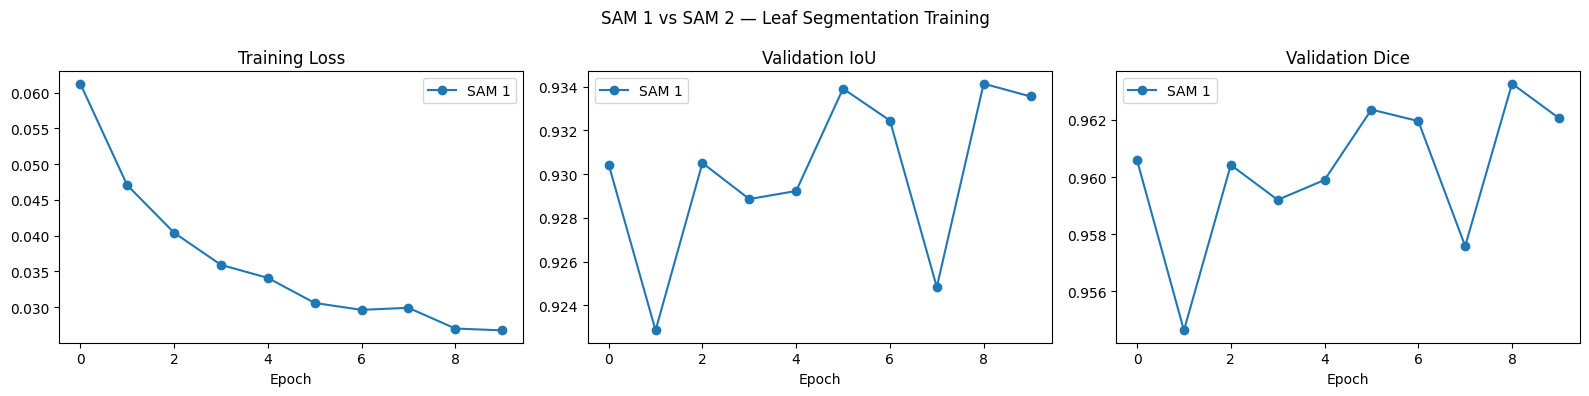

In [ ]:
# ============================================================
# CELL 12 — Plot SAM 1 vs SAM 2 training curves
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(sam1_history["train_loss"], marker='o', label="SAM 1")


axes[1].plot(sam1_history["val_iou"], marker='o', label="SAM 1")


axes[2].plot(sam1_history["val_dice"], marker='o', label="SAM 1")


plt.suptitle("SAM 1 vs SAM 2 — Leaf Segmentation Training", fontsize=12)
plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# CELL 13 — Load fine-tuned SAM 1 predictor
# ============================================================
sam1 = sam_model_registry[SAM1_MODEL_TYPE](checkpoint=SAM1_CHECKPOINT)
sam1.load_state_dict(torch.load(SAM1_FINETUNED, map_location=device))
sam1.to(device); sam1.eval()
predictor_sam1 = SamPredictor(sam1)
print("SAM 1 fine-tuned predictor ready.")

# Load SAM 2 predictor if available
predictor_sam2 = None
if SAM2_AVAILABLE:
    try:
        from sam2.build_sam import build_sam2
        from sam2.sam2_image_predictor import SAM2ImagePredictor
        sam2 = build_sam2(SAM2_MODEL_CFG, SAM2_CHECKPOINT, device=device)
        sam2.load_state_dict(torch.load(SAM2_FINETUNED, map_location=device))
        sam2.to(device); sam2.eval()
        predictor_sam2 = SAM2ImagePredictor(sam2)
        print("SAM 2 fine-tuned predictor ready.")
    except Exception as e:
        print(f"Could not load SAM 2 predictor: {e}")


Fine-tuned SAM loaded.


In [ ]:
# ============================================================
# CELL 14 — PlantVillage image loader
# ============================================================
VALID_EXTS = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}
plantvillage_paths = sorted([
    os.path.join(r, f)
    for r, _, files in os.walk(IMAGE_ROOT)
    for f in files if os.path.splitext(f)[1] in VALID_EXTS
])
print(f"PlantVillage images found: {len(plantvillage_paths)}")

def load_plantvillage_image(idx: int) -> np.ndarray:
    path  = plantvillage_paths[idx]
    image = cv2.imread(path)
    if image is None:
        raise FileNotFoundError(f"Could not read: {path}")
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

PlantVillage images found: 20638


In [ ]:
# ============================================================
# CELL 15 — Leaf segmentation inference helpers
# ============================================================
def detect_lesion_points(image: np.ndarray, n: int = 8) -> np.ndarray:
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    h, s, v = hsv[:,:,0], hsv[:,:,1], hsv[:,:,2]
    brown      = (h >=  5) & (h <= 25) & (s > 60) & (v > 40)
    yellow_brn = (h >= 20) & (h <= 35) & (s > 50) & (v > 60)
    necrotic   = (h >=  0) & (h <= 15) & (s > 40) & (v > 20) & (v < 120)
    lesion_map = (brown | yellow_brn | necrotic).astype(np.uint8)
    lesion_map = cv2.morphologyEx(lesion_map, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
    ys, xs     = np.where(lesion_map > 0)
    if len(xs) == 0:
        return np.empty((0, 2), dtype=np.int32)
    idx = np.random.choice(len(xs), size=min(n, len(xs)), replace=False)
    return np.stack([xs[idx], ys[idx]], axis=1)


def _build_prompts(image: np.ndarray):
    h, w = image.shape[:2]
    box  = np.array([5, 5, w - 5, h - 5])
    grid_pts   = np.array([[w//2,h//2],[w//3,h//2],[2*w//3,h//2],
                            [w//2,h//3],[w//2,2*h//3]])
    lesion_pts = detect_lesion_points(image, n=8)
    pts    = np.vstack([grid_pts, lesion_pts]) if len(lesion_pts) > 0 else grid_pts
    labels = np.ones(len(pts), dtype=np.int32)
    return pts, labels, box


def _post_process_leaf_mask(mask: np.ndarray) -> np.ndarray:
    """
    Post-processing shared by both SAM 1 and SAM 2:
      1. Morphological closing to connect near-touching regions.
      2. Keep only the largest connected component (removes stray blobs).
      3. Contour-based fill_holes to eliminate ALL interior holes,
         including those touching the leaf boundary (the main fix).
    """
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8))
    n_labels, labels_cc, stats, _ = cv2.connectedComponentsWithStats(mask)
    if n_labels > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask    = (labels_cc == largest).astype(np.uint8)
    mask = fill_holes(mask)   # contour-based: fills ALL holes without border leakage
    return mask


def get_leaf_mask_sam1(image: np.ndarray) -> np.ndarray:
    predictor_sam1.set_image(image)
    pts, labels, box = _build_prompts(image)
    masks, _, _ = predictor_sam1.predict(
        point_coords=pts, point_labels=labels, box=box, multimask_output=False)
    return _post_process_leaf_mask(masks[0].astype(np.uint8))


def get_leaf_mask_sam2(image: np.ndarray) -> np.ndarray:
    if predictor_sam2 is None:
        raise RuntimeError("SAM 2 predictor not available.")
    pts, labels, box = _build_prompts(image)
    with torch.inference_mode():
        predictor_sam2.set_image(image)
        masks, _, _ = predictor_sam2.predict(
            point_coords=pts, point_labels=labels, box=box, multimask_output=False)
    return _post_process_leaf_mask(masks[0].astype(np.uint8))


# Default active leaf mask function — uses SAM 1 (switch to SAM 2 if preferred)
def get_leaf_mask(image: np.ndarray, use_sam2: bool = False) -> np.ndarray:
    if use_sam2 and predictor_sam2 is not None:
        return get_leaf_mask_sam2(image)
    return get_leaf_mask_sam1(image)


# Sanity check — shows both SAM 1 and SAM 2 side by side
for check_idx in range(3):
    img  = load_plantvillage_image(check_idx)
    m1   = get_leaf_mask_sam1(img)
    fig, axes = plt.subplots(1, 3 if SAM2_AVAILABLE else 2, figsize=(12, 4))
    axes[0].imshow(img);              axes[0].set_title("Image");     axes[0].axis("off")
    axes[1].imshow(m1, cmap="gray");  axes[1].set_title("SAM 1 FT"); axes[1].axis("off")
    if SAM2_AVAILABLE:
        m2 = get_leaf_mask_sam2(img)
        axes[2].imshow(m2, cmap="gray"); axes[2].set_title("SAM 2 FT"); axes[2].axis("off")
    plt.suptitle(os.path.basename(plantvillage_paths[check_idx]), fontsize=9)
    plt.tight_layout(); plt.show()

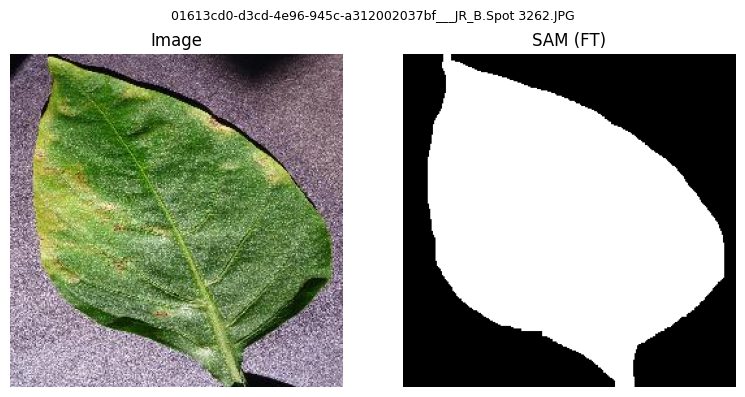

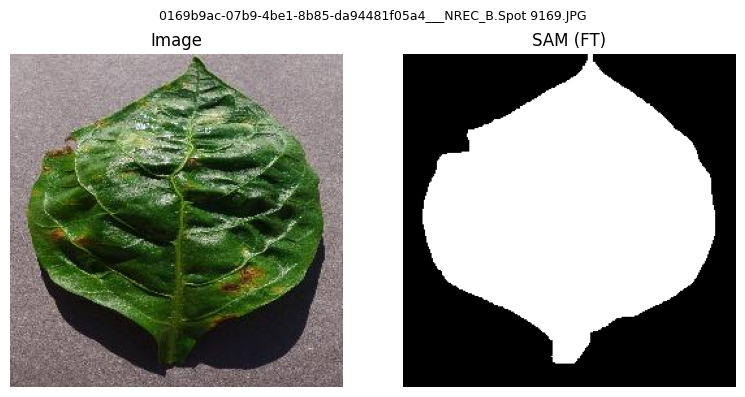

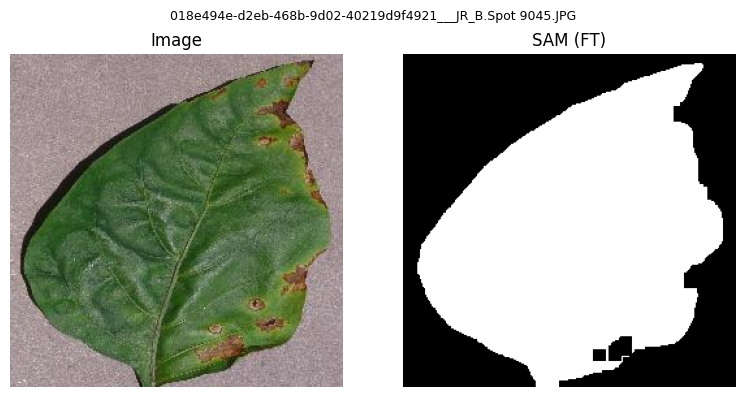

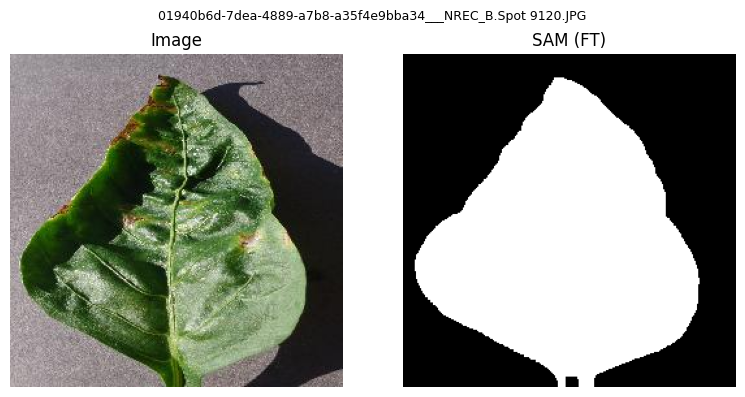

In [ ]:
# def get_leaf_mask(image: np.ndarray) -> np.ndarray:
#     """
#     Segments the leaf in `image` using the fine-tuned SAM predictor.
#     Uses a box prompt (full image, slightly inset) plus 5 centre-biased
#     point prompts — no GT mask needed at inference time.
#     """
#     predictor.set_image(image)
#     h, w = image.shape[:2]

#     # Box prompt: full image slightly inset
#     box = np.array([5, 5, w - 5, h - 5])

#     # 5 centre-biased point prompts
#     pts = np.array([
#         [w // 2, h // 2],
#         [w // 3, h // 2],
#         [2 * w // 3, h // 2],
#         [w // 2, h // 3],
#         [w // 2, 2 * h // 3],
#     ])
#     labels = np.ones(len(pts), dtype=np.int32)

#     masks, _, _ = predictor.predict(
#         point_coords=pts,
#         point_labels=labels,
#         box=box,
#         multimask_output=False,
#     )

#     mask = masks[0].astype(np.uint8)

#     # Morphological cleanup
#     mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8))

#     # Keep only the largest connected component
#     num_labels, labels_cc, stats, _ = cv2.connectedComponentsWithStats(mask)
#     if num_labels > 1:
#         largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
#         mask    = (labels_cc == largest).astype(np.uint8)

#     return mask


# # Quick sanity check on a few PlantVillage images
# for check_idx in range(3, 7):
#     img  = load_plantvillage_image(check_idx)
#     pred = get_leaf_mask(img)

#     plt.figure(figsize=(8, 4))
#     plt.subplot(1, 2, 1); plt.imshow(img);            plt.title("Image");    plt.axis("off")
#     plt.subplot(1, 2, 2); plt.imshow(pred, cmap="gray"); plt.title("SAM (FT)"); plt.axis("off")
#     plt.suptitle(os.path.basename(plantvillage_paths[check_idx]), fontsize=9)
#     plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# CELL 16 — Lesion dataset
# ============================================================
IMG_EXTS = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG", ".bmp", ".BMP"}

def _collect_pairs(img_dir, mask_dir):
    mask_map = {os.path.splitext(f)[0]: os.path.join(mask_dir, f)
                for f in os.listdir(mask_dir)}
    pairs = []
    for f in sorted(os.listdir(img_dir)):
        if os.path.splitext(f)[1] not in IMG_EXTS: continue
        stem = os.path.splitext(f)[0]
        if stem in mask_map:
            pairs.append((os.path.join(img_dir, f), mask_map[stem]))
    return pairs

lesion_pairs = []
for img_dir, mask_dir in LESION_DIRS:
    p = _collect_pairs(img_dir, mask_dir)
    print(f"  {img_dir}: {len(p)} pairs")
    lesion_pairs.extend(p)
print(f"Total lesion pairs: {len(lesion_pairs)}")

def load_lesion_pair_by_paths(img_path, mask_path):
    image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    mask  = (cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) > 0).astype(np.uint8)
    return image, mask

def load_lesion_pair(idx):
    return load_lesion_pair_by_paths(*lesion_pairs[idx])

def augment_lesion(img, mask):
    if random.random() < 0.5: img, mask = img[:, ::-1].copy(), mask[:, ::-1].copy()
    if random.random() < 0.3: img, mask = img[::-1].copy(),    mask[::-1].copy()
    k = random.randint(0, 3)
    img, mask = np.rot90(img, k).copy(), np.rot90(mask, k).copy()
    img  = cv2.resize(img,  (IMG_SIZE, IMG_SIZE))
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    alpha = random.uniform(0.85, 1.15); beta = random.randint(-20, 20)
    img = np.clip(img.astype(np.float32) * alpha + beta, 0, 255).astype(np.uint8)
    if random.random() < 0.4:
        hsv        = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.int32)
        hsv[:,:,0] = (hsv[:,:,0] + random.randint(-10, 10)) % 180
        hsv[:,:,1] = np.clip(hsv[:,:,1] + random.randint(-25, 25), 0, 255)
        img        = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
    if random.random() < 0.2:
        img = cv2.GaussianBlur(img, (3, 3), 0)
    return img, mask

class LesionDataset(Dataset):
    def __init__(self, indices, augment=False):
        self.indices = indices; self.augment = augment
    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        img, mask = load_lesion_pair_by_paths(*lesion_pairs[self.indices[idx]])
        if self.augment: img, mask = augment_lesion(img, mask)
        else:
            img  = cv2.resize(img,  (IMG_SIZE, IMG_SIZE))
            mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
        return (torch.tensor(img,  dtype=torch.float32).permute(2,0,1)/255.0,
                torch.tensor(mask, dtype=torch.float32).unsqueeze(0))

all_indices = list(range(len(lesion_pairs)))
random.seed(42); random.shuffle(all_indices); random.seed()
split     = int(0.8 * len(all_indices))
train_idx = all_indices[:split]
val_idx   = all_indices[split:]

train_ds     = LesionDataset(train_idx, augment=True)
val_ds       = LesionDataset(val_idx,   augment=False)
train_loader = DataLoader(train_ds, batch_size=LESION_BS, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=LESION_BS, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f"Lesion — train: {len(train_ds)}  val: {len(val_ds)}")

  /content/lesion_data/data/data/images: 588 pairs
  /content/lesion_data/aug_data/aug_data/images: 2940 pairs
Total lesion pairs: 3528
Lesion — train: 2822  val: 706


In [ ]:
# ============================================================
# CELL 17 — Shared lesion loss + mixup
# ============================================================
def focal_dice_loss(pred, target, alpha=0.75, gamma=2.0, dice_w=0.5, smooth=1e-6):
    prob     = torch.sigmoid(pred)
    bce_loss = F.binary_cross_entropy_with_logits(pred, target, reduction='none')
    p_t      = prob * target + (1 - prob) * (1 - target)
    alpha_t  = alpha * target + (1 - alpha) * (1 - target)
    focal    = (alpha_t * (1 - p_t) ** gamma * bce_loss).mean()
    inter    = (prob * target).sum(dim=(2, 3))
    denom    = prob.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
    dice     = 1 - ((2 * inter + smooth) / (denom + smooth)).mean()
    return (1 - dice_w) * focal + dice_w * dice

def mixup_batch(imgs, masks, alpha=0.4):
    lam  = np.random.beta(alpha, alpha)
    idx  = torch.randperm(imgs.size(0), device=imgs.device)
    return lam * imgs + (1-lam) * imgs[idx], lam * masks + (1-lam) * masks[idx]

def train_lesion_model(model, model_name, save_path, epochs,
                       train_loader, val_loader, lr=LESION_LR):
    """
    Generic training loop for any lesion segmentation model.
    Returns history dict with all tracked metrics.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=4, min_lr=1e-7)

    PATIENCE  = 12
    history   = {"train_loss":[], "train_iou":[], "val_loss":[], "val_iou":[], "val_dice":[]}
    best_iou  = 0.0
    patience_cnt = 0
    epoch_times  = []

    for epoch in range(epochs):
        t0 = time.time()
        model.train()
        t_loss = t_iou = 0.0
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            if random.random() < 0.5:
                imgs, masks = mixup_batch(imgs, masks)
            preds = model(imgs)
            loss  = focal_dice_loss(preds, masks)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            t_loss += loss.item()
            t_iou  += compute_iou_batch(preds, masks)

        model.eval()
        v_loss = v_iou = v_dice = 0.0
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                preds  = model(imgs)
                v_loss += focal_dice_loss(preds, masks).item()
                v_iou  += compute_iou_batch(preds, masks)
                p_bin  = (torch.sigmoid(preds) > 0.5).cpu().numpy().astype(np.uint8)
                g_bin  = masks.cpu().numpy().astype(np.uint8)
                for p, g in zip(p_bin, g_bin):
                    v_dice += compute_dice(p[0], g[0])

        n_tr = len(train_loader); n_vl = len(val_loader)
        avg_tl = t_loss/n_tr; avg_ti = t_iou/n_tr
        avg_vl = v_loss/n_vl; avg_vi = v_iou/n_vl
        avg_vd = v_dice / len(val_ds)

        scheduler.step(avg_vi)
        elapsed = time.time() - t0
        epoch_times.append(elapsed)

        history["train_loss"].append(avg_tl); history["train_iou"].append(avg_ti)
        history["val_loss"].append(avg_vl);   history["val_iou"].append(avg_vi)
        history["val_dice"].append(avg_vd)

        lr_now = optimizer.param_groups[0]["lr"]
        print(f"[{model_name}] Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {avg_tl:.4f} IoU: {avg_ti:.4f} | "
              f"Val Loss: {avg_vl:.4f} IoU: {avg_vi:.4f} Dice: {avg_vd:.4f} | "
              f"LR: {lr_now:.2e} | {elapsed:.1f}s")

        if avg_vi > best_iou:
            best_iou = avg_vi; patience_cnt = 0
            torch.save(model.state_dict(), save_path)
            print(f"  ✓ Saved best {model_name} (Val IoU={best_iou:.4f})")
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f"Early stopping at epoch {epoch+1}"); break

    model.load_state_dict(torch.load(save_path, map_location=device))
    history["best_val_iou"]   = best_iou
    history["avg_epoch_time"] = float(np.mean(epoch_times))
    print(f"\n{model_name} — Best Val IoU: {best_iou:.4f} | "
          f"Avg epoch time: {history['avg_epoch_time']:.1f}s")
    return history

In [ ]:
# ============================================================
# CELL 18 — Train UNet++ (existing model — kept unchanged)
# ============================================================
model_unet = smp.UnetPlusPlus(
    encoder_name="resnet50", encoder_weights="imagenet",
    in_channels=3, classes=1, decoder_attention_type="scse"
).to(device)

unet_history = train_lesion_model(
    model_unet, "UNet++", "lesion_unetpp_best.pth",
    UNET_EPOCHS, train_loader, val_loader
)

In [ ]:
# ============================================================
# CELL 18B — Save UNet++ history  ← run immediately after Cell 18
# ============================================================
import json

UNET_HISTORY_PATH = "unet_history.json"
with open(UNET_HISTORY_PATH, "w") as f:
    json.dump(unet_history, f, indent=2)
print(f"UNet++ history saved to {UNET_HISTORY_PATH}")

In [ ]:
# ============================================================
# CELL 18C — Load UNet++ history + reload model weights
#             ← run on a NEW session instead of Cell 18
#             Skip this cell if you just ran Cell 18 above.
# ============================================================
import json
UNET_HISTORY_PATH = "unet_history.json"
with open(UNET_HISTORY_PATH) as f:
    unet_history = json.load(f)
print(f"UNet++ history loaded — best Val IoU: {unet_history['best_val_iou']:.4f}")

# Rebuild and reload model weights so inference cells work
model_unet = smp.UnetPlusPlus(
    encoder_name="resnet50", encoder_weights=None,
    in_channels=3, classes=1, decoder_attention_type="scse"
).to(device)
model_unet.load_state_dict(torch.load("lesion_unetpp_best.pth", map_location=device))
model_unet.eval()
print("UNet++ weights reloaded.")

UNet++ history loaded — best Val IoU: 0.8728
UNet++ weights reloaded.


In [ ]:
# ============================================================
# CELL 19 — Train SegFormer-B2 (new model)
# ============================================================
# SegFormer uses a Mix Transformer (MiT-B2) encoder — a proper
# hierarchical vision transformer — with an all-MLP decoder.
# Published NeurIPS 2021. Trainable params: ~25M vs ~31M for UNet++.
model_segformer = smp.Segformer(
    encoder_name="mit_b2",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).to(device)

segformer_history = train_lesion_model(
    model_segformer, "SegFormer-B2", "lesion_segformer_best.pth",
    SEGFORMER_EPOCHS, train_loader, val_loader
)

[SegFormer-B2] Epoch 1/50 | Train Loss: 0.2227 IoU: 0.5448 | Val Loss: 0.1384 IoU: 0.6881 Dice: 0.8030 | LR: 1.00e-04 | 95.7s
  ✓ Saved best SegFormer-B2 (Val IoU=0.6881)
[SegFormer-B2] Epoch 2/50 | Train Loss: 0.1607 IoU: 0.6363 | Val Loss: 0.1139 IoU: 0.7297 Dice: 0.8341 | LR: 1.00e-04 | 87.6s
  ✓ Saved best SegFormer-B2 (Val IoU=0.7297)
[SegFormer-B2] Epoch 3/50 | Train Loss: 0.1520 IoU: 0.6492 | Val Loss: 0.1097 IoU: 0.7374 Dice: 0.8387 | LR: 1.00e-04 | 88.3s
  ✓ Saved best SegFormer-B2 (Val IoU=0.7374)
[SegFormer-B2] Epoch 4/50 | Train Loss: 0.1337 IoU: 0.6787 | Val Loss: 0.0964 IoU: 0.7572 Dice: 0.8542 | LR: 1.00e-04 | 86.3s
  ✓ Saved best SegFormer-B2 (Val IoU=0.7572)
[SegFormer-B2] Epoch 5/50 | Train Loss: 0.1276 IoU: 0.6904 | Val Loss: 0.0939 IoU: 0.7670 Dice: 0.8612 | LR: 1.00e-04 | 87.5s
  ✓ Saved best SegFormer-B2 (Val IoU=0.7670)
[SegFormer-B2] Epoch 6/50 | Train Loss: 0.1252 IoU: 0.6943 | Val Loss: 0.0928 IoU: 0.7638 Dice: 0.8588 | LR: 1.00e-04 | 87.2s
[SegFormer-B2] Epoc

In [ ]:
# ============================================================
# CELL 19B — Save SegFormer history  ← run immediately after Cell 19
# ============================================================
import json

SEGF_HISTORY_PATH = "segformer_history.json"
with open(SEGF_HISTORY_PATH, "w") as f:
    json.dump(segformer_history, f, indent=2)
print(f"SegFormer history saved to {SEGF_HISTORY_PATH}")

In [ ]:
# ============================================================
# CELL 19C — Load SegFormer history + reload model weights
#             ← run on a NEW session instead of Cell 19
#             Skip this cell if you just ran Cell 19 above.
# ============================================================
import json
SEGF_HISTORY_PATH = "segformer_history.json"
with open(SEGF_HISTORY_PATH) as f:
    segformer_history = json.load(f)
print(f"SegFormer history loaded — best Val IoU: {segformer_history['best_val_iou']:.4f}")

# Rebuild and reload model weights so inference cells work
model_segformer = smp.Segformer(
    encoder_name="mit_b2", encoder_weights=None,
    in_channels=3, classes=1,
).to(device)
model_segformer.load_state_dict(
    torch.load("lesion_segformer_best.pth", map_location=device))
model_segformer.eval()
print("SegFormer weights reloaded.")

In [ ]:
# ============================================================
# CELL 20A — MASTER LOAD: restore ALL histories in a fresh session
#             Run this cell INSTEAD of all training cells when you
#             already have saved history files from previous sessions.
#             After running this, jump straight to Cell 20 onwards.
# ============================================================
import json, os

def _load_history(path, name):
    if os.path.exists(path):
        with open(path) as f:
            h = json.load(f)
        print(f"✓ {name} history loaded — best Val IoU: {h.get('best_val_iou', '?'):.4f}")
        return h
    else:
        print(f"✗ {name} history NOT found at {path}")
        return None

sam1_history      = _load_history("sam1_history.json",      "SAM 1")
sam2_history      = _load_history("sam2_history.json",      "SAM 2")
# SAM2_AVAILABLE    = sam2_history is not None
SAM2_AVAILABLE    = False
unet_history      = _load_history("unet_history.json",      "UNet++")
segformer_history = _load_history("segformer_history.json", "SegFormer-B2")

# Reload model weights for inference (needed for Cells 21 onwards)
model_unet = smp.UnetPlusPlus(
    encoder_name="resnet50", encoder_weights=None,
    in_channels=3, classes=1, decoder_attention_type="scse"
).to(device)
model_unet.load_state_dict(torch.load("lesion_unetpp_best.pth", map_location=device))
model_unet.eval()

model_segformer = smp.Segformer(
    encoder_name="mit_b2", encoder_weights=None,
    in_channels=3, classes=1
).to(device)
model_segformer.load_state_dict(
    torch.load("lesion_segformer_best.pth", map_location=device))
model_segformer.eval()

sam1 = sam_model_registry[SAM1_MODEL_TYPE](checkpoint=SAM1_CHECKPOINT)
sam1.load_state_dict(torch.load(SAM1_FINETUNED, map_location=device))
sam1.to(device); sam1.eval()
predictor_sam1 = SamPredictor(sam1)

# if SAM2_AVAILABLE:
#     try:
#         from sam2.build_sam import build_sam2
#         from sam2.sam2_image_predictor import SAM2ImagePredictor
#         sam2 = build_sam2(SAM2_MODEL_CFG, SAM2_CHECKPOINT, device=device)
#         sam2.load_state_dict(torch.load(SAM2_FINETUNED, map_location=device))
#         sam2.to(device); sam2.eval()
#         predictor_sam2 = SAM2ImagePredictor(sam2)
#     except Exception as e:
#         print(f"SAM 2 predictor load failed: {e}")
#         predictor_sam2 = None
# else:
#     predictor_sam2 = None

print("\nAll histories and model weights restored.")

print("sam 2 not available.")

✓ SAM 1 history loaded — best Val IoU: 0.9341
✗ SAM 2 history NOT found at sam2_history.json
✓ UNet++ history loaded — best Val IoU: 0.8728
✓ SegFormer-B2 history loaded — best Val IoU: 0.8763


RuntimeError: PytorchStreamReader failed reading zip archive: failed finding central directory

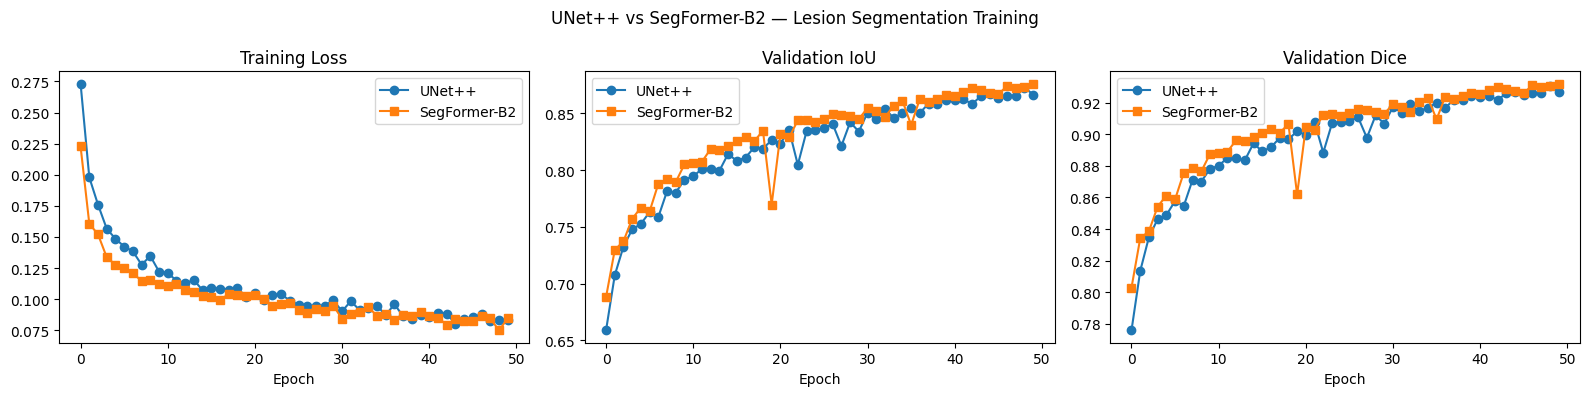

In [ ]:
# ============================================================
# CELL 20 — Plot UNet++ vs SegFormer training curves
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(unet_history["train_loss"],     marker='o', label="UNet++")
axes[0].plot(segformer_history["train_loss"],marker='s', label="SegFormer-B2")
axes[0].set_title("Training Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(unet_history["val_iou"],     marker='o', label="UNet++")
axes[1].plot(segformer_history["val_iou"],marker='s', label="SegFormer-B2")
axes[1].set_title("Validation IoU"); axes[1].set_xlabel("Epoch"); axes[1].legend()

axes[2].plot(unet_history["val_dice"],     marker='o', label="UNet++")
axes[2].plot(segformer_history["val_dice"],marker='s', label="SegFormer-B2")
axes[2].set_title("Validation Dice"); axes[2].set_xlabel("Epoch"); axes[2].legend()

plt.suptitle("UNet++ vs SegFormer-B2 — Lesion Segmentation Training", fontsize=12)
plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# CELL 21 — Lesion inference with TTA (works for any model)
# ============================================================
def _tta_predict(model, image: np.ndarray) -> np.ndarray:
    """8-fold TTA: 4 rotations × 2 flips. Returns averaged prob map."""
    model.eval()
    img_r    = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    prob_sum = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
    n        = 0

    def infer(arr):
        x = torch.tensor(arr, dtype=torch.float32).permute(2,0,1) \
                .unsqueeze(0).to(device) / 255.0
        with torch.no_grad():
            return torch.sigmoid(model(x)[0,0]).cpu().numpy()

    for k in range(4):
        rot  = np.rot90(img_r, k).copy()
        prob = infer(rot)
        prob_sum += np.rot90(prob, -k).copy(); n += 1
        flp  = rot[:, ::-1].copy()
        prob_sum += np.rot90(infer(flp)[:, ::-1], -k).copy(); n += 1

    avg  = prob_sum / n
    avg  = cv2.resize(avg, (image.shape[1], image.shape[0]))
    mask = (avg > 0.40).astype(np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  np.ones((3,3), np.uint8))
    mask = cv2.erode(mask,                          np.ones((3,3), np.uint8), iterations=1)
    return mask

def get_lesion_mask_unet(image):      return _tta_predict(model_unet,      image)
def get_lesion_mask_segformer(image): return _tta_predict(model_segformer,  image)

# Default — uses the better model (swap if SegFormer wins comparison)
def get_lesion_mask(image, use_segformer=False):
    return get_lesion_mask_segformer(image) if use_segformer \
           else get_lesion_mask_unet(image)

# Sanity check
img, gt = load_lesion_pair(2)
pred_u  = get_lesion_mask_unet(img)
pred_sf = get_lesion_mask_segformer(img)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(img);               axes[0].set_title("Image")
axes[1].imshow(gt,   cmap="gray"); axes[1].set_title("GT")
axes[2].imshow(pred_u,  cmap="gray"); axes[2].set_title("UNet++ Pred")
axes[3].imshow(pred_sf, cmap="gray"); axes[3].set_title("SegFormer Pred")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# CELL 22 — Full pipeline (uses active leaf + lesion models)
# ============================================================
def run_pipeline(idx, use_sam2=False, use_segformer=False):
    img         = load_plantvillage_image(idx)
    leaf_mask   = get_leaf_mask(img, use_sam2=use_sam2)
    lesion_mask = get_lesion_mask(img, use_segformer=use_segformer)
    lesion_mask = lesion_mask * leaf_mask
    severity    = float(lesion_mask.sum()) / (float(leaf_mask.sum()) + 1e-6)
    return img, leaf_mask, lesion_mask, severity

for sample_idx in range(5):
    img, leaf_pred, lesion_pred, severity = run_pipeline(sample_idx)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img);                       axes[0].set_title("Image")
    axes[1].imshow(leaf_pred,   cmap="gray");  axes[1].set_title("Leaf Mask")
    axes[2].imshow(lesion_pred, cmap="gray");  axes[2].set_title("Lesion Mask")
    for ax in axes: ax.axis("off")
    plt.suptitle(f"{os.path.basename(plantvillage_paths[sample_idx])} | "
                 f"Severity: {severity*100:.1f}%", fontsize=10)
    plt.tight_layout(); plt.show()
    print(f"Sample {sample_idx} — Severity: {severity*100:.2f}%")


In [ ]:
# ============================================================
# CELL 23 — Full evaluation with all metrics (paper-ready)
# ============================================================
print("\nEvaluating all models on held-out validation set...\n")

# ---- Lesion: UNet++ ----
unet_metrics_list = []
for i in range(len(val_ds)):
    img, gt = load_lesion_pair(val_idx[i])
    pred    = get_lesion_mask_unet(img)
    unet_metrics_list.append(full_metrics(pred, gt))
unet_agg = aggregate_metrics(unet_metrics_list)
print_metrics_table("Lesion Segmentation — UNet++ (ResNet50 + scSE)", unet_agg)

# ---- Lesion: SegFormer-B2 ----
segf_metrics_list = []
for i in range(len(val_ds)):
    img, gt = load_lesion_pair(val_idx[i])
    pred    = get_lesion_mask_segformer(img)
    segf_metrics_list.append(full_metrics(pred, gt))
segf_agg = aggregate_metrics(segf_metrics_list)
print_metrics_table("Lesion Segmentation — SegFormer-B2 (MiT-B2)", segf_agg)

# ---- Leaf: SAM 1 (visual only — no GT masks for PlantVillage) ----
# Leaf segmentation is evaluated on the Roboflow val set which has GT masks
print("\nEvaluating leaf segmentation on Roboflow validation set...")
rf_val_ds  = SAMLeafDataset(RF_VALID_JSON, RF_VALID_IMGS, augment=False)
sam1_leaf_metrics = []
sam2_leaf_metrics = []

for i in range(len(rf_val_ds)):
    img_t, mask_t, _ = rf_val_ds[i]
    # Reconstruct original image from tensor for inference
    pixel_mean = np.array([123.675, 116.28, 103.53], dtype=np.float32)
    pixel_std  = np.array([ 58.395,  57.12,  57.375], dtype=np.float32)
    img_np = (img_t.permute(1,2,0).numpy() * pixel_std + pixel_mean).clip(0,255).astype(np.uint8)
    gt_np  = mask_t[0].numpy().astype(np.uint8)

    # SAM 1
    pred_s1 = get_leaf_mask_sam1(img_np)
    # Resize pred to match gt if needed
    if pred_s1.shape != gt_np.shape:
        pred_s1 = cv2.resize(pred_s1, (gt_np.shape[1], gt_np.shape[0]),
                             interpolation=cv2.INTER_NEAREST)
    sam1_leaf_metrics.append(full_metrics(pred_s1, gt_np))

    # SAM 2
    if SAM2_AVAILABLE and predictor_sam2 is not None:
        try:
            pred_s2 = get_leaf_mask_sam2(img_np)
            if pred_s2.shape != gt_np.shape:
                pred_s2 = cv2.resize(pred_s2, (gt_np.shape[1], gt_np.shape[0]),
                                     interpolation=cv2.INTER_NEAREST)
            sam2_leaf_metrics.append(full_metrics(pred_s2, gt_np))
        except:
            pass

sam1_leaf_agg = aggregate_metrics(sam1_leaf_metrics)
print_metrics_table("Leaf Segmentation — SAM 1 Fine-tuned (ViT-B)", sam1_leaf_agg)

if sam2_leaf_metrics:
    sam2_leaf_agg = aggregate_metrics(sam2_leaf_metrics)
    print_metrics_table("Leaf Segmentation — SAM 2 Fine-tuned (Hiera-S)", sam2_leaf_agg)


Evaluating all models on held-out validation set...



NameError: name 'get_lesion_mask_unet' is not defined

NameError: name 'unet_agg' is not defined

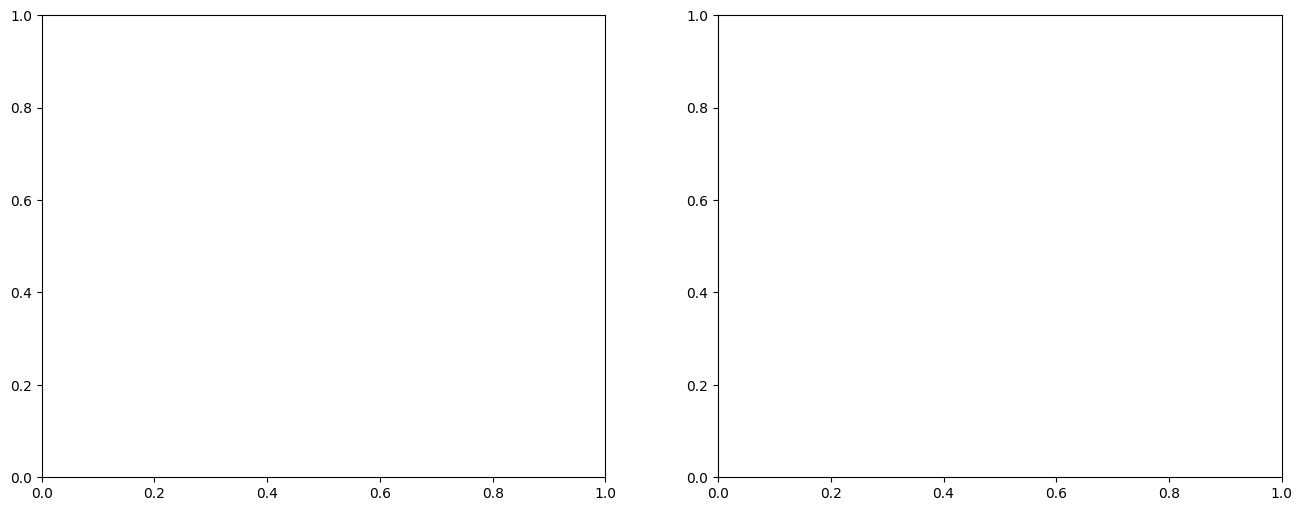

In [ ]:
# ============================================================
# CELL 24 — Side-by-side comparison bar chart (paper figure)
# ============================================================
metrics_to_plot = ["iou", "dice", "pixel_acc", "precision", "recall", "f1"]
labels          = ["IoU", "Dice", "Pixel Acc", "Precision", "Recall", "F1"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -- Lesion comparison --
x      = np.arange(len(metrics_to_plot))
width  = 0.35
unet_means = [unet_agg[m][0] for m in metrics_to_plot]
segf_means = [segf_agg[m][0] for m in metrics_to_plot]
unet_stds  = [unet_agg[m][1] for m in metrics_to_plot]
segf_stds  = [segf_agg[m][1] for m in metrics_to_plot]

axes[0].bar(x - width/2, unet_means, width, yerr=unet_stds, label="UNet++",
            color="#2196F3", capsize=4)
axes[0].bar(x + width/2, segf_means, width, yerr=segf_stds, label="SegFormer-B2",
            color="#FF9800", capsize=4)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=15)
axes[0].set_ylim(0, 1.05); axes[0].set_title("Lesion Segmentation — Model Comparison")
axes[0].set_ylabel("Score"); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# -- Leaf comparison --
sam1_means = [sam1_leaf_agg[m][0] for m in metrics_to_plot]
sam1_stds  = [sam1_leaf_agg[m][1] for m in metrics_to_plot]

if sam2_leaf_metrics:
    sam2_means = [sam2_leaf_agg[m][0] for m in metrics_to_plot]
    sam2_stds  = [sam2_leaf_agg[m][1] for m in metrics_to_plot]
    axes[1].bar(x - width/2, sam1_means, width, yerr=sam1_stds, label="SAM 1 FT",
                color="#4CAF50", capsize=4)
    axes[1].bar(x + width/2, sam2_means, width, yerr=sam2_stds, label="SAM 2 FT",
                color="#9C27B0", capsize=4)
else:
    axes[1].bar(x, sam1_means, width*1.5, yerr=sam1_stds, label="SAM 1 FT",
                color="#4CAF50", capsize=4)

axes[1].set_xticks(x); axes[1].set_xticklabels(labels, rotation=15)
axes[1].set_ylim(0, 1.05); axes[1].set_title("Leaf Segmentation — Model Comparison")
axes[1].set_ylabel("Score"); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle("Model Comparison — All Metrics (Val Set, Mean ± Std)", fontsize=13)
plt.tight_layout(); plt.show()


In [ ]:
# ============================================================
# CELL 25 — Training efficiency comparison (for paper table)
# ============================================================
print("\n" + "="*60)
print("  TRAINING EFFICIENCY COMPARISON")
print("="*60)
print(f"  {'Model':<28} {'Best IoU':>9}  {'Best Dice':>9}  {'Avg Epoch (s)':>13}")
print(f"  {'-'*58}")

rows = [
    ("SAM 1 FT (Leaf)",      sam1_history.get("best_val_iou",0),
                             max(sam1_history["val_dice"]),
                             sam1_history.get("avg_epoch_time",0)),
]
if sam2_history:
    rows.append(
    ("SAM 2 FT (Leaf)",      sam2_history.get("best_val_iou",0),
                             max(sam2_history["val_dice"]),
                             sam2_history.get("avg_epoch_time",0)))
rows += [
    ("UNet++ ResNet50 (Lesion)", unet_history.get("best_val_iou",0),
                                 max(unet_history["val_dice"]),
                                 unet_history.get("avg_epoch_time",0)),
    ("SegFormer-B2 (Lesion)",   segformer_history.get("best_val_iou",0),
                                 max(segformer_history["val_dice"]),
                                 segformer_history.get("avg_epoch_time",0)),
]

for name, iou, dice, t in rows:
    print(f"  {name:<28} {iou:>9.4f}  {dice:>9.4f}  {t:>13.1f}")
print("="*60)


In [ ]:
# ============================================================
# CELL 26 — Leaf segmentation visual check (random sample)
# ============================================================
sample_indices = random.sample(range(len(plantvillage_paths)),
                               min(10, len(plantvillage_paths)))
for i in sample_indices:
    img = load_plantvillage_image(i)
    m1  = get_leaf_mask_sam1(img)
    ncols = 3 if (SAM2_AVAILABLE and predictor_sam2) else 2
    fig, axes = plt.subplots(1, ncols, figsize=(4*ncols, 4))
    axes[0].imshow(img);             axes[0].set_title("Image");   axes[0].axis("off")
    axes[1].imshow(m1, cmap="gray"); axes[1].set_title("SAM 1");   axes[1].axis("off")
    if ncols == 3:
        m2 = get_leaf_mask_sam2(img)
        axes[2].imshow(m2, cmap="gray"); axes[2].set_title("SAM 2"); axes[2].axis("off")
    plt.suptitle(os.path.basename(plantvillage_paths[i]), fontsize=8)
    plt.tight_layout(); plt.show()
